# ER-CyRIS Siklus 2: Relationship Testing H1-H5

Notebook ini menguji hubungan empiris yang diperlukan untuk mengubah eksperimen M0-M4 menjadi bukti pembentuk **proposed ER-CyRIS framework**.

## Keputusan metodologis

- M1 dikeluarkan dari inferensi utama karena merupakan *implementation/no-op control* yang identik dengan M0.
- Metrik prediktif dideduplikasi terhadap K karena F1 yang sama direplikasi pada K = 5, 10, dan 20.
- Raw-telemetry-space dan transformed-feature-space dianalisis sebagai protokol perturbasi yang berbeda.
- H4 hanya bersifat eksploratif karena CSV tidak menyediakan *per-instance correctness* atau calibration output.
- Hasil statistik membentuk item dan hubungan framework; hasil ini belum merupakan validasi eksternal atau end-to-end.


In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', context='notebook')

try:
    from google.colab import drive as colab_drive, files as colab_files
    IN_COLAB = True
except ImportError:
    colab_drive = colab_files = None
    IN_COLAB = False

if IN_COLAB and not Path('/content/drive/MyDrive').exists():
    print('Google Drive belum terpasang. Memulai proses mount...')
    colab_drive.mount('/content/drive')

DRIVE_PROJECT_ROOT = Path('/content/drive/MyDrive/ercyris_siklus2')
SEARCH_ROOTS = [
    Path.cwd() / 'upload',
    Path.cwd(),
    Path('/content'),
    Path('/content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_audit'),
    Path('/content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence'),
]

def locate_existing(name):
    for root in SEARCH_ROOTS:
        p = root / name
        if p.exists():
            return p
    if DRIVE_PROJECT_ROOT.exists():
        matches = list(DRIVE_PROJECT_ROOT.rglob(name))
        if matches:
            return matches[0]
    return None

REQUIRED_FILES = [
    'cycle2_fss_FINAL_3600_20260920_145932.csv',
    'FINAL_EVIDENCE_MATRIX_CYCLE2.csv',
]
resolved = {name: locate_existing(name) for name in REQUIRED_FILES}
missing = [name for name, path in resolved.items() if path is None]

if missing and IN_COLAB:
    print('File berikut belum ditemukan di Google Drive:')
    for name in missing:
        print(' -', name)
    print('Silakan pilih file tersebut pada dialog unggah Colab.')
    uploaded = colab_files.upload()
    for name in missing:
        if name in uploaded:
            target = Path('/content') / name
            target.write_bytes(uploaded[name])
    resolved = {name: locate_existing(name) for name in REQUIRED_FILES}
    missing = [name for name, path in resolved.items() if path is None]

if missing:
    raise FileNotFoundError(
        'File input belum ditemukan: ' + ', '.join(missing) + '. '
        'Di Colab, izinkan mount Google Drive atau unggah kedua CSV ketika diminta.'
    )

RAW_PATH = resolved['cycle2_fss_FINAL_3600_20260920_145932.csv']
EVIDENCE_PATH = resolved['FINAL_EVIDENCE_MATRIX_CYCLE2.csv']
raw = pd.read_csv(RAW_PATH)
ev = pd.read_csv(EVIDENCE_PATH)

print('Raw FSS grid:', raw.shape, RAW_PATH)
print('Evidence matrix:', ev.shape, EVIDENCE_PATH)


Google Drive belum terpasang. Memulai proses mount...
Mounted at /content/drive
Raw FSS grid: (3600, 22) /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_audit/cycle2_fss_FINAL_3600_20260920_145932.csv
Evidence matrix: (240, 69) /content/drive/MyDrive/ercyris_siklus2/results/fss_cycle2_repair_v5/final_evidence/FINAL_EVIDENCE_MATRIX_CYCLE2.csv


## 1. Audit dan Evidence Freeze

Audit ini memastikan analisis tidak menggunakan pseudo-replikasi. M1 dipertahankan untuk verifikasi kontrol, tetapi tidak dipakai sebagai treatment substantif.


In [ ]:
audit = {
    'raw_rows': len(raw),
    'raw_columns': raw.shape[1],
    'evidence_rows': len(ev),
    'evidence_columns': ev.shape[1],
    'raw_missing_cells': int(raw.isna().sum().sum()),
    'evidence_missing_cells': int(ev.isna().sum().sum()),
    'raw_duplicate_rows': int(raw.duplicated().sum()),
    'evidence_duplicate_rows': int(ev.duplicated().sum()),
}

pred_keys = ['config','dataset','model','noise_protocol','sigma','noise_seed']
pred = raw.drop_duplicates(pred_keys).copy()
audit['predictive_rows_after_K_dedup'] = len(pred)

match_keys = ['dataset','model','noise_protocol','sigma','noise_seed','K']
m0 = raw[raw.config=='M0'].set_index(match_keys).sort_index()
m1 = raw[raw.config=='M1'].set_index(match_keys).sort_index()
numeric = [c for c in raw.select_dtypes(include=[np.number]).columns if c in m0.columns]
audit['M1_M0_max_numeric_abs_diff'] = float((m1[numeric]-m0[numeric]).abs().to_numpy().max())
audit['M1_M0_top_features_equal'] = bool(
    (m1.top_features_clean == m0.top_features_clean).all() and
    (m1.top_features_noisy == m0.top_features_noisy).all()
)

print(pd.Series(audit, name='value').to_string())
print('\nCounts per config raw:')
print(raw.config.value_counts().sort_index().to_string())
print('\nCounts per config evidence matrix:')
print(ev.config.value_counts().sort_index().to_string())


raw_rows                         3600
raw_columns                        22
evidence_rows                     240
evidence_columns                   69
raw_missing_cells                   0
evidence_missing_cells              0
raw_duplicate_rows                  0
evidence_duplicate_rows             0
predictive_rows_after_K_dedup    1200
M1_M0_max_numeric_abs_diff        0.0
M1_M0_top_features_equal         True

Counts per config raw:
config
M0    720
M1    720
M2    720
M3    720
M4    720

Counts per config evidence matrix:
config
M0    48
M1    48
M2    48
M3    48
M4    48


In [ ]:
# Helper functions used by H1-H5
RNG = np.random.default_rng(20260922)

def holm_adjust(pvals):
    p = np.asarray(pvals, float)
    order = np.argsort(p)
    out = np.empty_like(p)
    running = 0.0
    m = len(p)
    for rank, idx in enumerate(order):
        running = max(running, (m-rank)*p[idx])
        out[idx] = min(running, 1.0)
    return out

def rank_biserial_paired(diff):
    d = np.asarray(diff, float)
    d = d[np.isfinite(d) & (d != 0)]
    if len(d) == 0:
        return np.nan
    ranks = stats.rankdata(np.abs(d))
    pos, neg = ranks[d>0].sum(), ranks[d<0].sum()
    return float((pos-neg)/(pos+neg))

def matched_severity_test(df, value, unit_cols, protocol=None):
    x = df if protocol is None else df[df.noise_protocol==protocol]
    piv = x.pivot_table(index=unit_cols, columns='sigma', values=value, aggfunc='first')
    piv = piv.dropna(subset=[0.01,0.05,0.10])
    fr = stats.friedmanchisquare(piv[0.01], piv[0.05], piv[0.10])
    rows, ps = [], []
    for a,b in [(0.01,0.05),(0.01,0.10),(0.05,0.10)]:
        diff = piv[b]-piv[a]
        wt = stats.wilcoxon(piv[b], piv[a], zero_method='wilcox')
        rows.append({'comparison':f'{a:.2f}->{b:.2f}', 'median_change':np.median(diff),
                     'rank_biserial':rank_biserial_paired(diff), 'p_raw':wt.pvalue})
        ps.append(wt.pvalue)
    for row,padj in zip(rows,holm_adjust(ps)): row['p_holm']=padj
    return {
        'n_units':len(piv),
        'medians':{s:float(np.median(piv[s])) for s in [0.01,0.05,0.10]},
        'friedman_chi2':float(fr.statistic), 'friedman_p':float(fr.pvalue),
        'kendall_W':float(fr.statistic/(len(piv)*2)),
        'pairwise':pd.DataFrame(rows)
    }

def cluster_boot_spearman(df, x, y, cluster, repeats=500):
    dat = df[[x,y,cluster]].dropna()
    rho,p = stats.spearmanr(dat[x],dat[y])
    groups = [g for _,g in dat.groupby(cluster,sort=False)]
    vals=[]
    for _ in range(repeats):
        sample = pd.concat([groups[i] for i in RNG.integers(0,len(groups),len(groups))], ignore_index=True)
        rb = stats.spearmanr(sample[x],sample[y]).statistic
        if np.isfinite(rb): vals.append(rb)
    lo,hi = np.quantile(vals,[.025,.975])
    return {'n':len(dat),'clusters':len(groups),'rho':rho,'p':p,'ci95_low':lo,'ci95_high':hi}

def top_set(v):
    return set(str(v).split('|')) if pd.notna(v) and str(v) else set()

def jaccard(a,b):
    return len(a&b)/len(a|b) if a|b else np.nan

def ols_cluster(y, X, clusters):
    y, X = np.asarray(y,float), np.asarray(X,float)
    n,k = X.shape
    inv = np.linalg.pinv(X.T@X)
    beta = inv@X.T@y
    resid = y-X@beta
    groups = pd.Series(clusters).astype(str).to_numpy()
    uniq = np.unique(groups)
    meat = np.zeros((k,k))
    for g in uniq:
        ix=np.where(groups==g)[0]
        score=X[ix].T@resid[ix]
        meat += np.outer(score,score)
    correction=(len(uniq)/(len(uniq)-1))*((n-1)/(n-k))
    cov=correction*inv@meat@inv
    se=np.sqrt(np.clip(np.diag(cov),0,None))
    t=beta/se
    p=2*stats.t.sf(np.abs(t),df=len(uniq)-1)
    return beta,cov,se,t,p,len(uniq)

PRIMARY_CONFIGS = ['M0','M2','M3','M4']
pred_primary = pred[pred.config.isin(PRIMARY_CONFIGS)].copy()
raw_primary = raw[raw.config.isin(PRIMARY_CONFIGS)].copy()


## 2. H1 Perturbation Severity Menurunkan Predictive Robustness

**Outcome:** `predictive_F1_delta = F1_noisy - F1_clean`. Nilai yang semakin negatif berarti degradasi semakin besar. Pengujian menggunakan kondisi yang dipasangkan pada tiga severity.


Matched units: 320
Median F1 delta: {0.01: -0.458218, 0.05: -0.6354249999999999, 0.1: -0.6745785}
Friedman chi2=456.475, p=7.55e-100, Kendall W=0.713

Pairwise Wilcoxon with Holm correction:
comparison  median_change  rank_biserial        p_raw       p_holm
0.01->0.05      -0.089877      -0.939394 5.371458e-43 1.074292e-42
0.01->0.10      -0.135310      -0.991856 1.071560e-48 3.214681e-48
0.05->0.10      -0.036571      -0.923981 4.078109e-40 4.078109e-40


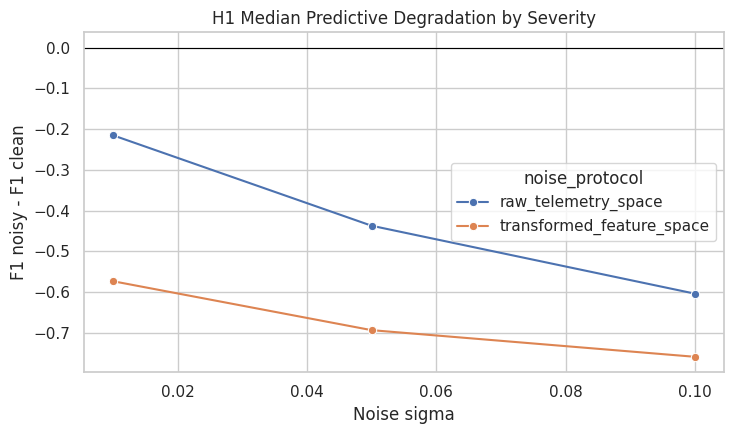

In [ ]:
h1 = matched_severity_test(
    pred_primary, 'predictive_F1_delta',
    ['config','dataset','model','noise_protocol','noise_seed']
)
print('Matched units:', h1['n_units'])
print('Median F1 delta:', h1['medians'])
print(f"Friedman chi2={h1['friedman_chi2']:.3f}, p={h1['friedman_p']:.3g}, Kendall W={h1['kendall_W']:.3f}")
print('\nPairwise Wilcoxon with Holm correction:')
print(h1['pairwise'].to_string(index=False))

h1_plot = (pred_primary.groupby(['noise_protocol','sigma'])['predictive_F1_delta']
           .median().reset_index())
fig, ax = plt.subplots(figsize=(7.5,4.5))
sns.lineplot(data=h1_plot,x='sigma',y='predictive_F1_delta',hue='noise_protocol',marker='o',ax=ax)
ax.axhline(0,color='black',lw=.8)
ax.set(title='H1 Median Predictive Degradation by Severity',ylabel='F1 noisy - F1 clean',xlabel='Noise sigma')
plt.tight_layout(); plt.show()


**Keputusan H1:** didukung. Severity menunjukkan efek besar dan konsisten. Namun, besarnya degradasi berbeda menurut protocol, dataset, model, dan konfigurasi; karena itu hubungan tidak boleh ditulis sebagai konstanta universal.


## 3. H2 Evidence Integrity Memengaruhi Explanation Reliability

H2 diuji dengan lima metrik komplementer. FSS tidak diperlakukan sebagai satu-satunya definisi reliabilitas penjelasan.


                    metric  n_units  median_sigma_001  median_sigma_005  median_sigma_010    friedman_p  kendall_W
         FSS_instance_mean      960          0.811331          0.745429          0.730119 8.309014e-187   0.446319
         rank_spearman_rho      960          0.978222          0.968510          0.963446 2.212706e-197   0.471682
     weighted_topk_overlap      960          0.838926          0.800305          0.786518 1.572768e-112   0.268163
magnitude_stability_global      960          0.755234          0.706340          0.668730 1.554657e-211   0.505629
   sign_consistency_global      960          0.861093          0.797770          0.760661  0.000000e+00   0.920156

Protocol contrast:
                    metric    n  median_transformed_minus_raw  rank_biserial         p_raw        p_holm
         FSS_instance_mean 1440                     -0.021887      -0.920220 4.201070e-118 1.680428e-117
         rank_spearman_rho 1440                     -0.002237      -0.456442  3.

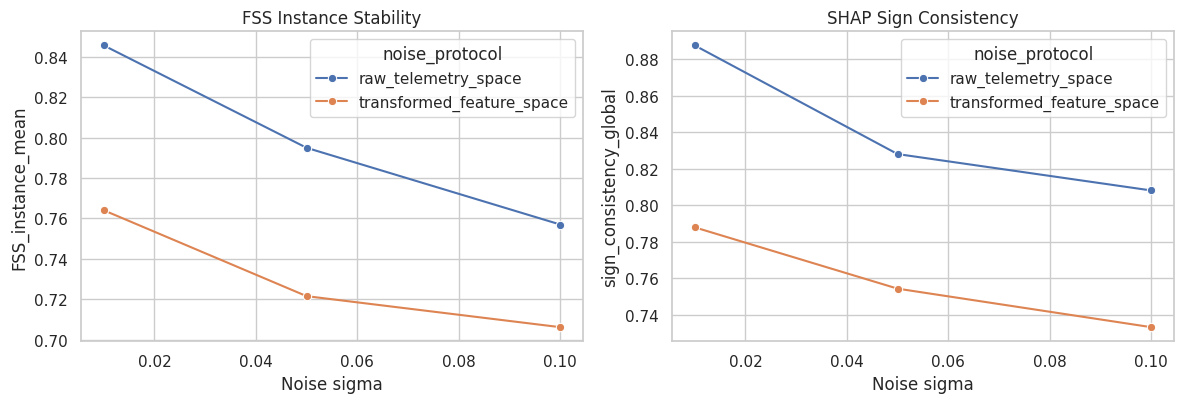

In [ ]:
exp_metrics = ['FSS_instance_mean','rank_spearman_rho','weighted_topk_overlap',
               'magnitude_stability_global','sign_consistency_global']
exp_unit = ['config','dataset','model','noise_protocol','noise_seed','K']
h2_rows=[]
for metric in exp_metrics:
    result=matched_severity_test(raw_primary,metric,exp_unit)
    h2_rows.append({'metric':metric,'n_units':result['n_units'],
                    'median_sigma_001':result['medians'][0.01],
                    'median_sigma_005':result['medians'][0.05],
                    'median_sigma_010':result['medians'][0.10],
                    'friedman_p':result['friedman_p'],'kendall_W':result['kendall_W']})
h2_table=pd.DataFrame(h2_rows)
print(h2_table.to_string(index=False))

contrast=[]
for metric in exp_metrics:
    piv=raw_primary.pivot_table(index=['config','dataset','model','sigma','noise_seed','K'],
                                columns='noise_protocol',values=metric,aggfunc='first').dropna()
    diff=piv['transformed_feature_space']-piv['raw_telemetry_space']
    wt=stats.wilcoxon(piv['transformed_feature_space'],piv['raw_telemetry_space'],zero_method='wilcox')
    contrast.append({'metric':metric,'n':len(piv),'median_transformed_minus_raw':np.median(diff),
                     'rank_biserial':rank_biserial_paired(diff),'p_raw':wt.pvalue})
contrast=pd.DataFrame(contrast)
contrast['p_holm']=holm_adjust(contrast.p_raw)
print('\nProtocol contrast:')
print(contrast.to_string(index=False))

plot_h2=(raw_primary.groupby(['noise_protocol','sigma'])[exp_metrics].median().reset_index())
fig, axes=plt.subplots(1,2,figsize=(12,4.2))
sns.lineplot(data=plot_h2,x='sigma',y='FSS_instance_mean',hue='noise_protocol',marker='o',ax=axes[0])
sns.lineplot(data=plot_h2,x='sigma',y='sign_consistency_global',hue='noise_protocol',marker='o',ax=axes[1])
axes[0].set_title('FSS Instance Stability'); axes[1].set_title('SHAP Sign Consistency')
for ax in axes: ax.set_xlabel('Noise sigma')
plt.tight_layout(); plt.show()


**Keputusan H2:** didukung dengan heterogenitas. Severity yang meningkat menurunkan stabilitas pada seluruh keluarga metrik, tetapi ukuran efek dan perbedaan protocol tidak identik. Ini mendukung domain **Evidence Integrity → Explanation Reliability**, bukan klaim bahwa satu skor FSS mewakili seluruh reliabilitas.


## 4. H3 Predictive Robustness dan Explanation Reliability Tidak Selalu Bergerak Bersama

Analisis menggunakan gain relatif terhadap M0 pada M2-M4. Confidence interval dihitung dengan cluster bootstrap berdasarkan kondisi dataset-model-protocol-severity.


                             metric   n  clusters       rho            p  ci95_low  ci95_high
               FSS_global_gain_avgK 144        48 -0.044239 5.985422e-01 -0.242053   0.160517
             FSS_instance_gain_avgK 144        48  0.024552 7.702083e-01 -0.190536   0.244106
         weighted_overlap_gain_avgK 144        48  0.002672 9.746469e-01 -0.231503   0.217137
      rank_spearman_mean_gain_vs_M0 144        48  0.094751 2.586259e-01 -0.125622   0.284746
magnitude_stability_mean_gain_vs_M0 144        48  0.530293 8.162747e-12  0.375587   0.653293
   sign_consistency_mean_gain_vs_M0 144        48  0.462289 5.444694e-09  0.230365   0.629509

Quadrant counts:
quadrant  both_decline  both_improve  robust_down_FSS_up  robust_up_FSS_down  tie_or_zero
config                                                                                   
M2                  11            11                   1                  10           15
M3                   9             3                  

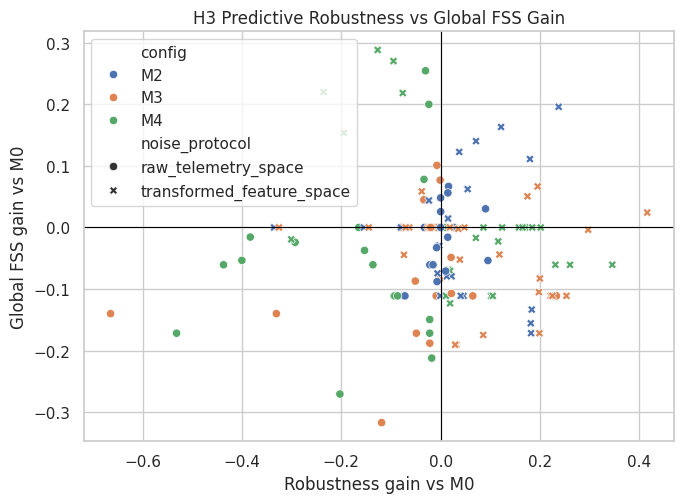

In [ ]:
h3df=ev[ev.config.isin(['M2','M3','M4'])].copy()
h3df['condition_cluster']=h3df[['dataset','model','noise_protocol','sigma']].astype(str).agg('|'.join,axis=1)
h3df['FSS_global_gain_avgK']=h3df[[f'FSS_global_mean_K{k}_gain_vs_M0' for k in [5,10,20]]].mean(axis=1)
h3df['FSS_instance_gain_avgK']=h3df[[f'FSS_instance_mean_K{k}_gain_vs_M0' for k in [5,10,20]]].mean(axis=1)
h3df['weighted_overlap_gain_avgK']=h3df[[f'weighted_overlap_mean_K{k}_gain_vs_M0' for k in [5,10,20]]].mean(axis=1)
h3_metrics=['FSS_global_gain_avgK','FSS_instance_gain_avgK','weighted_overlap_gain_avgK',
            'rank_spearman_mean_gain_vs_M0','magnitude_stability_mean_gain_vs_M0',
            'sign_consistency_mean_gain_vs_M0']
h3corr=pd.DataFrame([
    {'metric':m,**cluster_boot_spearman(h3df,'robustness_delta_mean_gain_vs_M0',m,'condition_cluster')}
    for m in h3_metrics
])
print(h3corr.to_string(index=False))

x=h3df.robustness_delta_mean_gain_vs_M0
y=h3df.FSS_global_gain_avgK
tol=1e-12
h3df['quadrant']=np.select(
    [(x>tol)&(y>tol),(x>tol)&(y<-tol),(x<-tol)&(y>tol),(x<-tol)&(y<-tol)],
    ['both_improve','robust_up_FSS_down','robust_down_FSS_up','both_decline'],default='tie_or_zero')
quadrants=pd.crosstab(h3df.config,h3df.quadrant)
print('\nQuadrant counts:')
print(quadrants.to_string())

fig, ax=plt.subplots(figsize=(7,5.2))
sns.scatterplot(data=h3df,x='robustness_delta_mean_gain_vs_M0',y='FSS_global_gain_avgK',hue='config',style='noise_protocol',ax=ax)
ax.axhline(0,color='black',lw=.8); ax.axvline(0,color='black',lw=.8)
ax.set(title='H3 Predictive Robustness vs Global FSS Gain',xlabel='Robustness gain vs M0',ylabel='Global FSS gain vs M0')
plt.tight_layout(); plt.show()


**Keputusan H3:** didukung sebagai pola non-monotonik, bukan sebagai bukti bahwa kedua konsep selalu independen. Global FSS, instance FSS, ranking, magnitude, dan sign consistency menghasilkan hubungan yang berbeda. Karena itu ER-CyRIS membutuhkan dua kanal bukti: predictive reliability dan explanation reliability.


## 5. H4 Cross-Model Explanation Agreement dan Prediction Reliability

CSV memungkinkan perhitungan Jaccard Top-K antara Random Forest dan XGBoost. Namun outcome yang tersedia hanya F1 agregat, bukan correctness per instance atau calibration error. Karena itu analisis ini adalah **proxy exploratory analysis**.


In [ ]:
join_keys=['config','dataset','noise_protocol','sigma','noise_seed','K']
rf=raw_primary[raw_primary.model=='RandomForest'].set_index(join_keys)
xg=raw_primary[raw_primary.model=='XGBoost'].set_index(join_keys)
paired=rf.join(xg,lsuffix='_RF',rsuffix='_XGB',how='inner').reset_index()
paired['cross_model_jaccard_noisy']=[jaccard(top_set(a),top_set(b)) for a,b in zip(paired.top_features_noisy_RF,paired.top_features_noisy_XGB)]
paired['mean_noisy_F1']=paired[['predictive_F1_noisy_RF','predictive_F1_noisy_XGB']].mean(axis=1)
paired['mean_delta']=paired[['predictive_F1_delta_RF','predictive_F1_delta_XGB']].mean(axis=1)
paired['condition_cluster']=paired[['config','dataset','noise_protocol','sigma','noise_seed']].astype(str).agg('|'.join,axis=1)

h4_overall=pd.DataFrame([
    {'outcome':'mean_noisy_F1',**cluster_boot_spearman(paired,'cross_model_jaccard_noisy','mean_noisy_F1','condition_cluster')},
    {'outcome':'mean_F1_delta',**cluster_boot_spearman(paired,'cross_model_jaccard_noisy','mean_delta','condition_cluster')},
])
print('Overall exploratory proxy:')
print(h4_overall.to_string(index=False))

by_ds=[]
for ds,g in paired.groupby('dataset'):
    r=cluster_boot_spearman(g,'cross_model_jaccard_noisy','mean_noisy_F1','condition_cluster',repeats=300)
    by_ds.append({'dataset':ds,**r})
h4_by_dataset=pd.DataFrame(by_ds)
print('\nAgreement vs mean noisy F1 by dataset:')
print(h4_by_dataset.to_string(index=False))


Overall exploratory proxy:
      outcome    n  clusters       rho            p  ci95_low  ci95_high
mean_noisy_F1 1440       480 -0.351764 3.376228e-43 -0.415441  -0.278519
mean_F1_delta 1440       480 -0.142258 5.919764e-08 -0.212713  -0.059135

Agreement vs mean noisy F1 by dataset:
   dataset   n  clusters       rho        p  ci95_low  ci95_high
       BGL 360       120  0.081154 0.124303 -0.033817   0.188167
CICIDS2018 360       120  0.014986 0.776899 -0.053662   0.076812
      HDFS 360       120 -0.048445 0.359397 -0.099620   0.004675
 UNSW-NB15 360       120  0.084999 0.107386  0.015049   0.155143


**Keputusan H4:** belum dapat dikonfirmasi. Korelasi agregat dipengaruhi komposisi dataset dan bahkan berubah menjadi lemah ketika dianalisis per dataset. Untuk menguji H4 secara sah dibutuhkan prediksi per instance, label aktual, probabilitas terkalibrasi, dan explanation agreement per instance.


## 6. H5 Efek Contextual Anomaly Evidence M3 Bersifat Condition Dependent

M3 dibandingkan langsung dengan M2 pada kondisi dataset-model-protocol-severity-seed yang sama. Gain positif berarti M3 mengalami degradasi yang lebih kecil.


n=240, mean gain=0.007583, median gain=0.009851
positive=133, zero=17, negative=90
Wilcoxon p=0.0209758, rank-biserial=0.178

Dataset-model cells:
   dataset        model  n  mean_gain  median_gain  rank_biserial        p_raw       p_holm
       BGL RandomForest 30  -0.003245    -0.018653      -0.165591 4.399668e-01 1.000000e+00
       BGL      XGBoost 30   0.004050     0.009851       0.294624 1.526400e-01 7.632001e-01
CICIDS2018 RandomForest 30   0.012323    -0.012536       0.109677 6.120056e-01 1.000000e+00
CICIDS2018      XGBoost 30   0.006967     0.000000       0.162055 5.053366e-01 1.000000e+00
      HDFS RandomForest 30  -0.190302    -0.074765      -0.754839 3.062744e-04 2.143921e-03
      HDFS      XGBoost 30   0.187149     0.191285       1.000000 1.862645e-09 1.490116e-08
 UNSW-NB15 RandomForest 30   0.044686     0.022361       0.753333 1.244102e-03 7.464611e-03
 UNSW-NB15      XGBoost 30  -0.000959     0.000000      -0.029101 8.948718e-01 1.000000e+00

Dataset x model interact

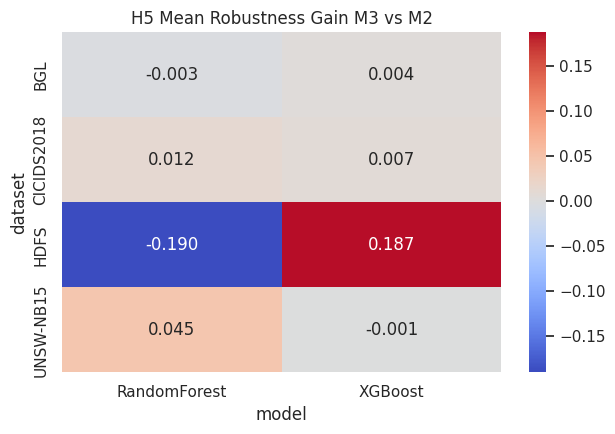

In [ ]:
keys=['dataset','model','noise_protocol','sigma','noise_seed']
m2=pred[pred.config=='M2'].set_index(keys)
m3=pred[pred.config=='M3'].set_index(keys)
h5df=m2[['predictive_F1_delta','predictive_F1_noisy']].join(
    m3[['predictive_F1_delta','predictive_F1_noisy']],lsuffix='_M2',rsuffix='_M3').reset_index()
h5df['gain']=h5df.predictive_F1_delta_M3-h5df.predictive_F1_delta_M2
overall=stats.wilcoxon(h5df.gain,zero_method='wilcox')
print(f"n={len(h5df)}, mean gain={h5df.gain.mean():.6f}, median gain={h5df.gain.median():.6f}")
print(f"positive={(h5df.gain>0).sum()}, zero={(h5df.gain==0).sum()}, negative={(h5df.gain<0).sum()}")
print(f"Wilcoxon p={overall.pvalue:.6g}, rank-biserial={rank_biserial_paired(h5df.gain):.3f}")

cells=[]
for (ds,model),g in h5df.groupby(['dataset','model']):
    try: p=stats.wilcoxon(g.gain,zero_method='wilcox').pvalue
    except ValueError: p=1.0
    cells.append({'dataset':ds,'model':model,'n':len(g),'mean_gain':g.gain.mean(),
                  'median_gain':g.gain.median(),'rank_biserial':rank_biserial_paired(g.gain),'p_raw':p})
h5_cells=pd.DataFrame(cells)
h5_cells['p_holm']=holm_adjust(h5_cells.p_raw)
print('\nDataset-model cells:')
print(h5_cells.to_string(index=False))

# Cluster-robust fixed-effect model for the dataset x model interaction block.
X=pd.DataFrame({'Intercept':1.0,'sigma_x100':h5df.sigma*100,
                'protocol_transformed':(h5df.noise_protocol=='transformed_feature_space').astype(float),
                'model_XGB':(h5df.model=='XGBoost').astype(float)})
for ds in ['CICIDS2018','HDFS','UNSW-NB15']:
    X[f'dataset_{ds}']=(h5df.dataset==ds).astype(float)
for ds in ['CICIDS2018','HDFS','UNSW-NB15']:
    X[f'{ds}_x_XGB']=X[f'dataset_{ds}']*X.model_XGB
clusters=h5df[['dataset','model','noise_protocol','noise_seed']].astype(str).agg('|'.join,axis=1)
beta,cov,se,t,p,G=ols_cluster(h5df.gain,X,clusters)
interaction_idx=[X.columns.get_loc(f'{ds}_x_XGB') for ds in ['CICIDS2018','HDFS','UNSW-NB15']]
b=beta[interaction_idx]; V=cov[np.ix_(interaction_idx,interaction_idx)]
F=float((b.T@np.linalg.pinv(V)@b)/len(interaction_idx))
p_inter=stats.f.sf(F,len(interaction_idx),G-1)
print(f"\nDataset x model interaction block: F({len(interaction_idx)},{G-1})={F:.3f}, p={p_inter:.3g}")

heat=h5_cells.pivot(index='dataset',columns='model',values='mean_gain')
fig, ax=plt.subplots(figsize=(6.4,4.5))
sns.heatmap(heat,annot=True,fmt='.3f',center=0,cmap='coolwarm',ax=ax)
ax.set_title('H5 Mean Robustness Gain M3 vs M2')
plt.tight_layout(); plt.show()


**Keputusan H5:** didukung sebagai efek kondisional. Rata-rata keseluruhan M3 sedikit positif, tetapi HDFS-RandomForest memburuk tajam sementara HDFS-XGBoost membaik tajam. Karena itu contextual anomaly evidence tidak boleh ditulis sebagai modul yang selalu meningkatkan robustness.


## 7. Keputusan Hipotesis dan Konsekuensi Framework


In [ ]:
h3_global=h3corr[h3corr.metric=='FSS_global_gain_avgK'].iloc[0]
discordant=int(((h3df.quadrant=='robust_up_FSS_down') | (h3df.quadrant=='robust_down_FSS_up')).sum())

decisions=pd.DataFrame([
    ['H1','SUPPORTED',f"Severity effect p={h1['friedman_p']:.3g}; Kendall W={h1['kendall_W']:.3f}."],
    ['H2','SUPPORTED WITH HETEROGENEITY',f"FSS-instance severity p={h2_table.iloc[0].friedman_p:.3g}; multiple metrics and protocol contrasts significant."],
    ['H3','SUPPORTED AS NON-MONOTONIC',f"Global FSS rho={h3_global.rho:.3f}; cluster-bootstrap CI {h3_global.ci95_low:.3f} to {h3_global.ci95_high:.3f}; discordant={discordant}/144."],
    ['H4','PARTIALLY TESTABLE; NOT CONFIRMATORY','Only aggregate F1 proxy exists; per-instance correctness and calibration are absent.'],
    ['H5','SUPPORTED AS CONDITION DEPENDENT',f"Mean M3-M2 gain={h5df.gain.mean():.4f}; dataset x model interaction p={p_inter:.3g}."],
],columns=['Hypothesis','Decision','Evidence'])
print(decisions.to_string(index=False))


Hypothesis                             Decision                                                                                Evidence
        H1                            SUPPORTED                                           Severity effect p=7.55e-100; Kendall W=0.713.
        H2         SUPPORTED WITH HETEROGENEITY FSS-instance severity p=8.31e-187; multiple metrics and protocol contrasts significant.
        H3           SUPPORTED AS NON-MONOTONIC         Global FSS rho=-0.044; cluster-bootstrap CI -0.242 to 0.161; discordant=51/144.
        H4 PARTIALLY TESTABLE; NOT CONFIRMATORY    Only aggregate F1 proxy exists; per-instance correctness and calibration are absent.
        H5     SUPPORTED AS CONDITION DEPENDENT                         Mean M3-M2 gain=0.0076; dataset x model interaction p=2.64e-13.


## 8. Framework Implications

Hasil ini mendukung tiga hubungan inti untuk proposed ER-CyRIS:

1. **Evidence Integrity → Robust Detection**: severity berpengaruh kuat terhadap degradasi prediksi.
2. **Evidence Integrity → Explanation Reliability**: severity dan protocol memengaruhi stabilitas ranking, membership, magnitude, dan sign.
3. **Robust Detection ↔ Explanation Reliability**: hubungan tidak monoton, sehingga keduanya harus dipertahankan sebagai domain terpisah yang bertemu pada reliability gate.

Hasil ini belum mendukung dua klaim berikut:

- bahwa cross-model explanation agreement otomatis meningkatkan prediction correctness;
- bahwa contextual anomaly evidence selalu memperbaiki robustness.

## 9. Eksperimen Berikutnya yang Diperlukan

- simpan prediksi, probabilitas, label, dan SHAP per instance untuk menguji H4;
- tambahkan calibration metrics seperti Brier score dan ECE;
- uji missingness dan temporal/distribution drift;
- bekukan dataset eksternal sebelum threshold reliability gate dipilih;
- validasi reliability gate terhadap detector-only dan detector-plus-XAI baselines.

**Batas interpretasi:** notebook ini adalah relationship testing pada evidence Siklus 2. Ia belum membuktikan contextual risk, response decision, real-time performance, atau generalisasi lintas organisasi.
